# Multimineral Analysis Using Well Logs

## Objective

This project estimates the volumetric composition of calcite, dolomite, pyrite and effective porosity from density, neutron porosity and photoelectric well logs. A constrained optimization approach is used to minimize the mismatch between measured and predicted log responses while satisfying the mineral volume balance.

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import minimize

plt.style.use("ggplot")

In [4]:
OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"Output folder created: {OUTPUT_DIR}")

Output folder created: outputs


## Load Well Log Dataset

In [5]:
INPUT_FILE = "well_logs.csv"

df = pd.read_csv(INPUT_FILE)

print(f"Dataset Loaded Successfully")
print(f"Number of Samples : {len(df)}")

df.head()

Dataset Loaded Successfully
Number of Samples : 3413


,Depth,RHOB,NPHI,PEF,Vsh
0,3098.5,2.5399,0.0961,7.7100,0.042949
1,3098.6,2.5789,0.0932,7.5277,0.041138
2,3098.7,2.5917,0.0893,7.5301,0.038317
3,3098.8,2.5920,0.0846,7.5670,0.035613
4,3098.9,2.5909,0.0799,7.6240,0.033962


## Data Preprocessing

In [6]:
required_columns = [
    "Depth",
    "RHOB",
    "NPHI",
    "PEF",
    "Vsh"
]

df = (
    df[required_columns]
    .apply(pd.to_numeric, errors="coerce")
    .dropna()
    .reset_index(drop=True)
)

print(df.info())
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3413 entries, 0 to 3412
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Depth   3413 non-null   float64
 1   RHOB    3413 non-null   float64
 2   NPHI    3413 non-null   float64
 3   PEF     3413 non-null   float64
 4   Vsh     3413 non-null   float64
dtypes: float64(5)
memory usage: 133.4 KB
None


,Depth,RHOB,NPHI,PEF,Vsh
0,3098.5,2.5399,0.0961,7.7100,0.042949
1,3098.6,2.5789,0.0932,7.5277,0.041138
2,3098.7,2.5917,0.0893,7.5301,0.038317
3,3098.8,2.5920,0.0846,7.5670,0.035613
4,3098.9,2.5909,0.0799,7.6240,0.033962


## Shale Correction

The measured log responses are corrected for shale contribution before estimating mineral fractions.

In [7]:
RHOB_SHALE = 2.22
NPHI_SHALE = 0.55
PEF_SHALE = 7.27

df["RHOB_ns"] = (
    df["RHOB"] - df["Vsh"] * RHOB_SHALE
) / (1 - df["Vsh"])

df["NPHI_ns"] = (
    df["NPHI"] - df["Vsh"] * NPHI_SHALE
) / (1 - df["Vsh"])

df["PEF_ns"] = (
    df["PEF"] - df["Vsh"] * PEF_SHALE
) / (1 - df["Vsh"])

df.head()

,Depth,RHOB,NPHI,PEF,Vsh,RHOB_ns,NPHI_ns,PEF_ns
0,3098.5,2.5399,0.0961,7.7100,0.042949,2.554256,0.075731,7.729745
1,3098.6,2.5789,0.0932,7.5277,0.041138,2.594298,0.073602,7.538756
2,3098.7,2.5917,0.0893,7.5301,0.038317,2.606510,0.070944,7.540463
3,3098.8,2.5920,0.0846,7.5670,0.035613,2.605737,0.067413,7.577968
4,3098.9,2.5909,0.0799,7.6240,0.033962,2.603939,0.063373,7.636445


## Mineral End-Member Properties

In [8]:
CALCITE = [2.71, 0.00, 5.10]

DOLOMITE = [2.87, 0.02, 3.10]

PYRITE = [5.01, 0.04, 17.00]

FLUID = [1.00, 1.00, 0.00]

## Optimization-Based Multimineral Analysis

The mineral fractions are estimated using constrained nonlinear optimization. The objective is to minimize the difference between measured and predicted well log responses while satisfying the volume closure constraint.

In [9]:
def objective_function(x, rhob, nphi, pef):

    calcite, dolomite, pyrite, porosity = x

    rhob_pred = (
        calcite * CALCITE[0]
        + dolomite * DOLOMITE[0]
        + pyrite * PYRITE[0]
        + porosity * FLUID[0]
    )

    nphi_pred = (
        calcite * CALCITE[1]
        + dolomite * DOLOMITE[1]
        + pyrite * PYRITE[1]
        + porosity * FLUID[1]
    )

    pef_pred = (
        calcite * CALCITE[2]
        + dolomite * DOLOMITE[2]
        + pyrite * PYRITE[2]
    )

    error = (
        (rhob_pred - rhob) ** 2
        + (nphi_pred - nphi) ** 2
        + (pef_pred - pef) ** 2
    )

    return error

In [10]:
def volume_constraint(x):
    return np.sum(x) - 1

## Mineral Volume Estimation

In [11]:
calcite_volume = []
dolomite_volume = []
pyrite_volume = []
porosity = []

rhob_predicted = []
nphi_predicted = []
pef_predicted = []

In [12]:
for _, row in df.iterrows():

    solution = minimize(
        objective_function,
        x0=[0.4, 0.3, 0.1, 0.2],
        args=(
            row["RHOB_ns"],
            row["NPHI_ns"],
            row["PEF_ns"]
        ),
        method="SLSQP",
        bounds=[(0, 1)] * 4,
        constraints={
            "type": "eq",
            "fun": volume_constraint
        }
    )

    volumes = solution.x / solution.x.sum()

    calcite_volume.append(volumes[0])
    dolomite_volume.append(volumes[1])
    pyrite_volume.append(volumes[2])
    porosity.append(volumes[3])

    rhob_predicted.append(
        volumes[0] * CALCITE[0]
        + volumes[1] * DOLOMITE[0]
        + volumes[2] * PYRITE[0]
        + volumes[3] * FLUID[0]
    )

    nphi_predicted.append(
        volumes[0] * CALCITE[1]
        + volumes[1] * DOLOMITE[1]
        + volumes[2] * PYRITE[1]
        + volumes[3] * FLUID[1]
    )

    pef_predicted.append(
        volumes[0] * CALCITE[2]
        + volumes[1] * DOLOMITE[2]
        + volumes[2] * PYRITE[2]
    )

## Store Estimated Mineral Volumes

In [13]:
df["Calcite"] = calcite_volume
df["Dolomite"] = dolomite_volume
df["Pyrite"] = pyrite_volume
df["Porosity"] = porosity

df["RHOB_Predicted"] = rhob_predicted
df["NPHI_Predicted"] = nphi_predicted
df["PEF_Predicted"] = pef_predicted

df.head()

,Depth,RHOB,NPHI,PEF,Vsh,RHOB_ns,NPHI_ns,PEF_ns,Calcite,Dolomite,Pyrite,Porosity,RHOB_Predicted,NPHI_Predicted,PEF_Predicted
0,3098.5,2.5399,0.0961,7.7100,0.042949,2.554256,0.075731,7.729745,0.292345,8.529109e-17,0.362397,0.345258,2.953122,0.359754,7.651709
1,3098.6,2.5789,0.0932,7.5277,0.041138,2.594298,0.073602,7.538756,0.358840,2.682896e-17,0.331779,0.309381,2.944051,0.322652,7.470328
2,3098.7,2.5917,0.0893,7.5301,0.038317,2.606510,0.070944,7.540463,0.368800,3.164283e-17,0.328966,0.302234,2.949801,0.315393,7.473300
3,3098.8,2.5920,0.0846,7.5670,0.035613,2.605737,0.067413,7.577968,0.364014,6.386249e-17,0.332529,0.303457,2.955904,0.316758,7.509459
4,3098.9,2.5909,0.0799,7.6240,0.033962,2.603939,0.063373,7.636445,0.354782,0.000000e+00,0.338618,0.306600,2.964536,0.320145,7.565896


## Quality Control Parameters

In [14]:
df["Bulk_Porosity"] = df["Porosity"] * (1 - df["Vsh"])

df["Volume_Closure"] = (
    df["Calcite"]
    + df["Dolomite"]
    + df["Pyrite"]
    + df["Porosity"]
)

df["RMSE"] = np.sqrt(
    (df["RHOB_Predicted"] - df["RHOB_ns"]) ** 2
    + (df["NPHI_Predicted"] - df["NPHI_ns"]) ** 2
    + (df["PEF_Predicted"] - df["PEF_ns"]) ** 2
)

df.head()

,Depth,RHOB,NPHI,PEF,Vsh,RHOB_ns,NPHI_ns,PEF_ns,Calcite,Dolomite,Pyrite,Porosity,RHOB_Predicted,NPHI_Predicted,PEF_Predicted,Bulk_Porosity,Volume_Closure,RMSE
0,3098.5,2.5399,0.0961,7.7100,0.042949,2.554256,0.075731,7.729745,0.292345,8.529109e-17,0.362397,0.345258,2.953122,0.359754,7.651709,0.330429,1.0,0.495836
1,3098.6,2.5789,0.0932,7.5277,0.041138,2.594298,0.073602,7.538756,0.358840,2.682896e-17,0.331779,0.309381,2.944051,0.322652,7.470328,0.296653,1.0,0.434782
2,3098.7,2.5917,0.0893,7.5301,0.038317,2.606510,0.070944,7.540463,0.368800,3.164283e-17,0.328966,0.302234,2.949801,0.315393,7.473300,0.290653,1.0,0.426749
3,3098.8,2.5920,0.0846,7.5670,0.035613,2.605737,0.067413,7.577968,0.364014,6.386249e-17,0.332529,0.303457,2.955904,0.316758,7.509459,0.292650,1.0,0.435296
4,3098.9,2.5909,0.0799,7.6240,0.033962,2.603939,0.063373,7.636445,0.354782,0.000000e+00,0.338618,0.306600,2.964536,0.320145,7.565896,0.296187,1.0,0.448262


## Export Results

The estimated mineral fractions and quality control parameters are exported for further reservoir evaluation.

In [15]:
result_columns = [
    "Depth",
    "Calcite",
    "Dolomite",
    "Pyrite",
    "Porosity",
    "Bulk_Porosity",
    "Volume_Closure",
    "RMSE"
]

results = df[result_columns].round(4)

results.to_csv(
    f"{OUTPUT_DIR}/multimineral_analysis_results.csv",
    index=False
)

print("Results exported successfully.")

results.head()

Results exported successfully.


,Depth,Calcite,Dolomite,Pyrite,Porosity,Bulk_Porosity,Volume_Closure,RMSE
0,3098.5,0.2923,0.0,0.3624,0.3453,0.3304,1.0,0.4958
1,3098.6,0.3588,0.0,0.3318,0.3094,0.2967,1.0,0.4348
2,3098.7,0.3688,0.0,0.3290,0.3022,0.2907,1.0,0.4267
3,3098.8,0.3640,0.0,0.3325,0.3035,0.2926,1.0,0.4353
4,3098.9,0.3548,0.0,0.3386,0.3066,0.2962,1.0,0.4483


## Volume Closure Analysis

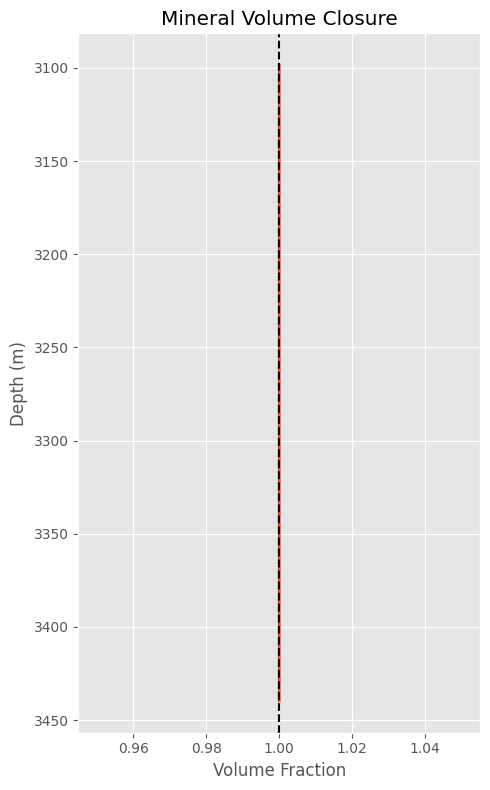

In [16]:
plt.figure(figsize=(5,8))

plt.plot(
    df["Volume_Closure"],
    df["Depth"],
    linewidth=2
)

plt.axvline(
    1,
    color="black",
    linestyle="--"
)

plt.gca().invert_yaxis()

plt.xlabel("Volume Fraction")
plt.ylabel("Depth (m)")
plt.title("Mineral Volume Closure")

plt.grid(True)

plt.tight_layout()

plt.savefig(
    f"{OUTPUT_DIR}/volume_closure.png",
    dpi=300
)

plt.show()

## Optimization Error

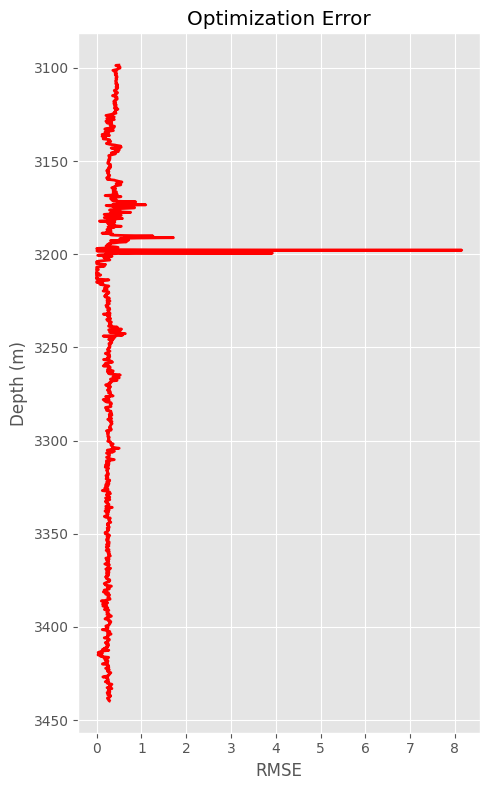

In [17]:
plt.figure(figsize=(5,8))

plt.plot(
    df["RMSE"],
    df["Depth"],
    color="red",
    linewidth=2
)

plt.gca().invert_yaxis()

plt.xlabel("RMSE")
plt.ylabel("Depth (m)")

plt.title("Optimization Error")

plt.grid(True)

plt.tight_layout()

plt.savefig(
    f"{OUTPUT_DIR}/rmse.png",
    dpi=300
)

plt.show()

## Estimated Mineral Composition

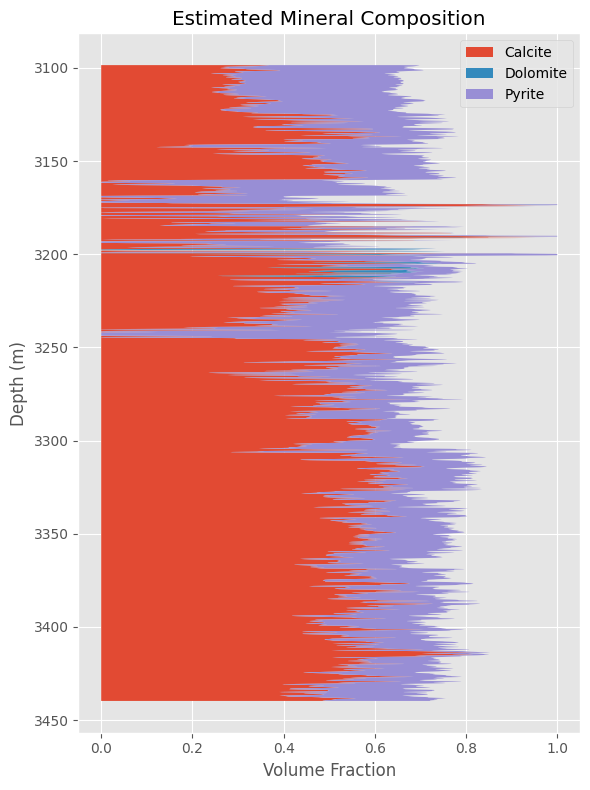

In [18]:
plt.figure(figsize=(6,8))

plt.fill_betweenx(
    df["Depth"],
    0,
    df["Calcite"],
    label="Calcite"
)

plt.fill_betweenx(
    df["Depth"],
    df["Calcite"],
    df["Calcite"] + df["Dolomite"],
    label="Dolomite"
)

plt.fill_betweenx(
    df["Depth"],
    df["Calcite"] + df["Dolomite"],
    df["Calcite"] + df["Dolomite"] + df["Pyrite"],
    label="Pyrite"
)

plt.gca().invert_yaxis()

plt.xlabel("Volume Fraction")
plt.ylabel("Depth (m)")

plt.title("Estimated Mineral Composition")

plt.legend()

plt.tight_layout()

plt.savefig(
    f"{OUTPUT_DIR}/mineral_composition.png",
    dpi=300
)

plt.show()

## Porosity Profile

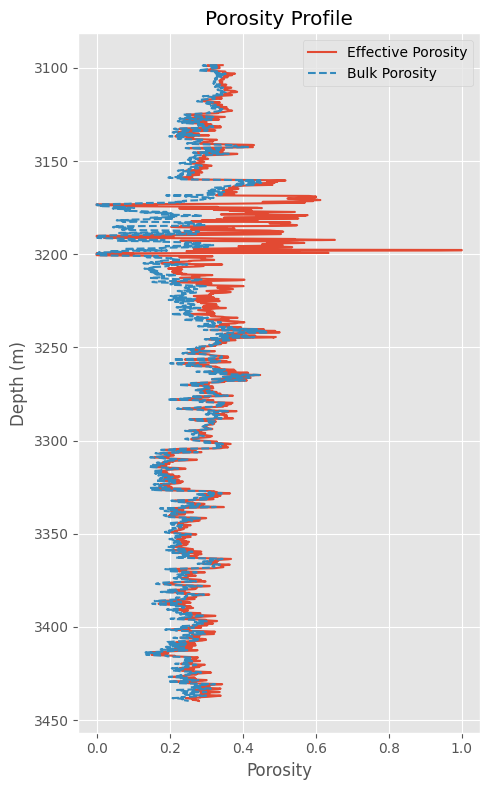

In [19]:
plt.figure(figsize=(5,8))

plt.plot(
    df["Porosity"],
    df["Depth"],
    label="Effective Porosity"
)

plt.plot(
    df["Bulk_Porosity"],
    df["Depth"],
    "--",
    label="Bulk Porosity"
)

plt.gca().invert_yaxis()

plt.xlabel("Porosity")
plt.ylabel("Depth (m)")

plt.title("Porosity Profile")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig(
    f"{OUTPUT_DIR}/porosity.png",
    dpi=300
)

plt.show()

## Measured vs Predicted Well Logs

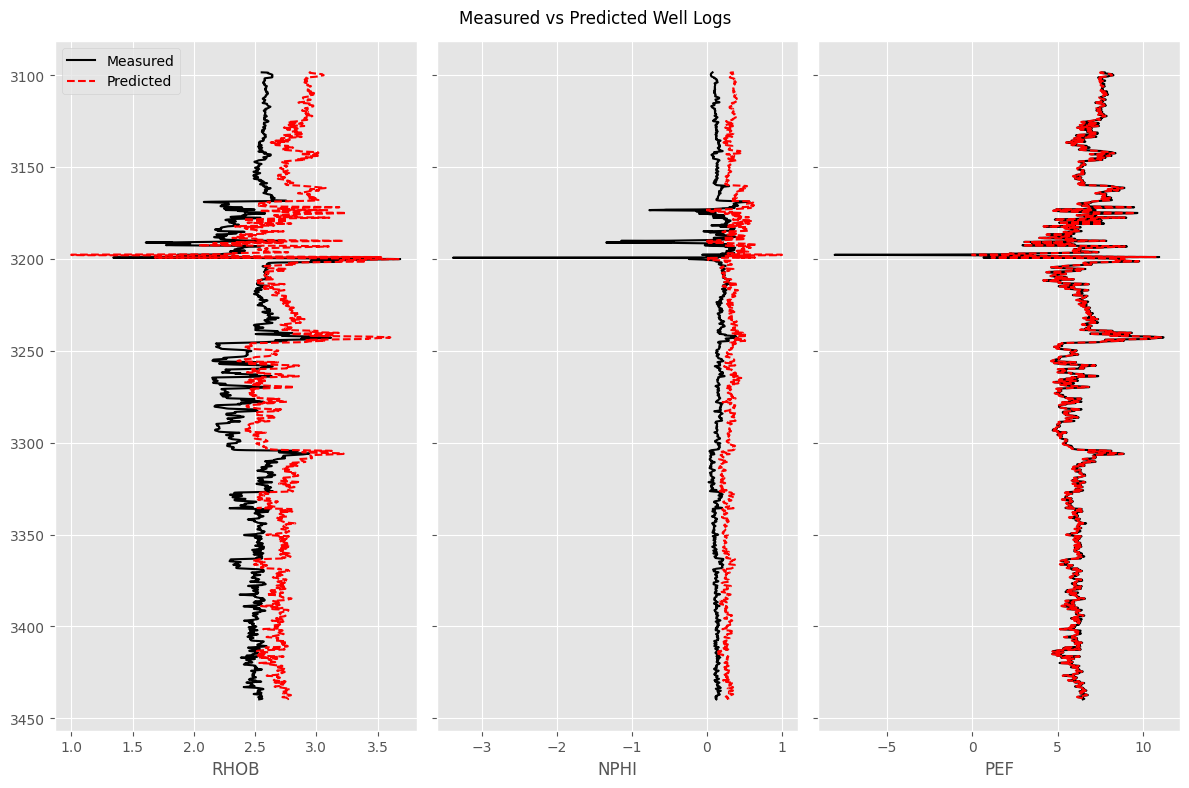

In [20]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(12,8),
    sharey=True
)

axes[0].plot(
    df["RHOB_ns"],
    df["Depth"],
    color="black",
    label="Measured"
)

axes[0].plot(
    df["RHOB_Predicted"],
    df["Depth"],
    "--",
    color="red",
    label="Predicted"
)

axes[0].set_xlabel("RHOB")

axes[1].plot(
    df["NPHI_ns"],
    df["Depth"],
    color="black"
)

axes[1].plot(
    df["NPHI_Predicted"],
    df["Depth"],
    "--",
    color="red"
)

axes[1].set_xlabel("NPHI")

axes[2].plot(
    df["PEF_ns"],
    df["Depth"],
    color="black"
)

axes[2].plot(
    df["PEF_Predicted"],
    df["Depth"],
    "--",
    color="red"
)

axes[2].set_xlabel("PEF")

for ax in axes:
    ax.invert_yaxis()
    ax.grid(True)

axes[0].legend()

plt.suptitle("Measured vs Predicted Well Logs")

plt.tight_layout()

plt.savefig(
    f"{OUTPUT_DIR}/log_matching.png",
    dpi=300
)

plt.show()

## Project Summary

In [21]:
print("=" * 60)
print("MULTIMINERAL ANALYSIS SUMMARY")
print("=" * 60)

print(f"Total Samples Analysed : {len(df)}")

print(f"Average Calcite Volume  : {df['Calcite'].mean():.3f}")
print(f"Average Dolomite Volume : {df['Dolomite'].mean():.3f}")
print(f"Average Pyrite Volume   : {df['Pyrite'].mean():.3f}")
print(f"Average Porosity        : {df['Porosity'].mean():.3f}")

print(f"Average RMSE            : {df['RMSE'].mean():.4f}")

print("\nOutput files saved in:")
print(OUTPUT_DIR)

print("\nProject completed successfully.")

MULTIMINERAL ANALYSIS SUMMARY
Total Samples Analysed : 3413
Average Calcite Volume  : 0.470
Average Dolomite Volume : 0.005
Average Pyrite Volume   : 0.225
Average Porosity        : 0.300
Average RMSE            : 0.2950

Output files saved in:
outputs

Project completed successfully.
